# Contexto de cambios semánticos de palabras en proyecto de ley de salud


**Objetivo**

Se analizan los títulos de proyectos de ley de salud presentados entre 2009 y 2024 correspondientes a los períodos de sesiones 127 a 141 en la Cámara de Diputados de la Nación Argentina. Para más información [sesiones](https://www.hcdn.gob.ar/sesiones/index.html) .

Un proyecto es de ley sobre salud, si tiene indicado el tipo de proyecto como "LEY" y el primer giro a comisión (comisión cabecera) es a una comisión vinculada a salud ('accion social y salud publica', 'asistencia social y salud publica', 'salud' o 'salud y deporte').

**Método**

Se identificaron 2848 proyectos de ley sobre salud. Se limpiaron los textos de los títulos de los proyectos. Se generaron corpus (colección cuidadosamente seleccionada y organizada de textos) para períodos quinquenales (2009,2014 y2019). 

    Período 2009: Periodos parlamentarios 127-131 (03/2009 - 02/2014)
    Período 2014: Periodos parlamentarios 132-136 (03/2014 - 02/2019)
    Período 2019: Periodos parlamentarios 137-141 (03/2019 - 02/2024)

Se construyeron modelos de word embedding por períodos a comparar. Word embedding es un método utilizado en el procesamiento del lenguaje natural para representar palabras o documentos como vectores numéricos. La selección de parámetros para un modelo word embedding en corpus pequeños se baso en la evaluación sobre una muestra de palabras en los distintos períodos. Determinada la combinación de parámetros para los corpus pequeños, se continuo con la identificación de enfoque estable para la deteccion de cambios semánticos de palabras entre periodos quinquenales consecutivos, es decir cambios de palabras entre 2009 vs 2014 y 2014 vs 2019.
Se exploraron dos enfoques, Procrustes y NN. Para analizar la estabilidad de enfoque se evaluó cuantitativa y cualitativamente ambos enfoques y comparó. 

Aplicamos la comparación a la tarea de detección de cambios en el uso de palabras por par de período comparado y enfoque. 
Utilizamos la intersección @k, propuesta por Gonen et al., que mide el porcentaje de palabras compartidas en las k palabras más cambiadas durante varios reinicios, cambiando cada vez la semilla aleatoria.

Calculamos las palabras comunes cambiadas en las repeticiones. Específicamente, ejecutamos cada enfoque de cambio de uso y recopilamos las k palabras más cambiadas, donde k ∈ k = [50,  100,  150,  200,  250,  300,  350,  400,  450,  500,  550,
        600,  650,  700,  750,  800,  850,  900,  950, 1000]. Luego, para cada uno de las combinaciones de elementos tomados de 2 en 2  de ejecuciones diferentes y para cada uno de los valores de k, medimos el porcentaje de palabras compartidas en las predicciones de palabras con mayor cambio de cada enfoque. **Un valor de cero entre un par de ejecuciones significa que no hay palabras compartidas en sus predicciones, lo que indica alta variabilidad, mientras que un valor de uno indica alta estabilidad.**

Intersección @k: mide el porcentaje de palabras compartidas en las predicciones de k palabras con mayor cambio por par de ejecuciones.
* Valor cercano a 1.0 : alta estabilidad, resultados consistentes.
* Valor cercano a 0.0 : alta variabilidad, resultados sensibles a la semilla.

Se determino que el enfoque de Procruste para k=250 palabras es el modelo que permite analizar el cambio semántico de palabras entre pares de períodos quinquenales. Para cada palabra, se calcula el promedio de similaridad coseno (medida de estabilidad del modelo) Este valor es estimado junto con los respectivos intervalos de confianza del 95%, utilizando el método bootstrap.


**Config modelo word embedding**

https://radimrehurek.com/gensim/models/word2vec.html

* tam_vector = 50  # Dimensionalidad de los vectores de palabras.
* ventana = 5 # ventana ( int , opcional ): distancia máxima entre la palabra actual y la palabra prevista dentro de una oración.
* min_frec = 2 #  Ignora todas las palabras con una frecuencia total menor que esta.
* w = 1  # utilice estos muchos subprocesos de trabajo para entrenar el modelo (=entrenamiento más rápido con máquinas de múltiples núcleos).
* s = 1 # Algoritmo de entrenamiento: 1 para skip-gram; de lo contrario, CBOW.
* e = 100 # Número de iteraciones (épocas) en el corpus. (Anteriormente: iter )
* semilla = 1 # seed ( int , opcional ): Semilla para el generador de números aleatorios. 
* iteracion = 50


* Par de periodos (2009, 2014) : Esto indica los pares de periodos comparados [2009, 2014) vs  [2014, 2019)
* Par de periodos (2014, 2019) : Esto indica los pares de periodos comparados [2014, 2019) vs [2019, 2024)




 

In [22]:
# Importar librería
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import pickle
import os
import re
import random as rn
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import bootstrap
import matplotlib.pyplot as plt
import itertools
from scipy.spatial.distance import cosine
from scipy import stats

from ast import literal_eval
from gensim.models import Word2Vec
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
tqdm.pandas()


In [2]:
# Configurar
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
modelo_dir =  RESULTADOS_DIR+ '/archivos_out/modelos_swmwosge_5051100'
pd.set_option('display.max_colwidth', None)

In [3]:
RESULTADOS_DIR

'C:/Users/Usuario/iamas_iniciativasleg_salud/src/data/'

In [4]:
# Abrir OBJETO
with open(modelo_dir+'/top250_periodos_NN_df.pkl', 'rb') as file: 
    topn_periodo = pickle.load(file) ## Diccionario

In [7]:
pares_periodo = [ (2009, 2014),(2014, 2019)]
similitud = []
topk = 20
plt.figure(figsize=(8, 5))
for par_periodo in pares_periodo:

    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True)
    df.to_csv(RESULTADOS_DIR+'NN_top20_'+str(par_periodo[0])+'.csv', index=False)
    print("*************************")
    print(par_periodo)
    print("*************************")
    print(df.shape)
    display(df.head(topk))
    display(df.describe())
    similitud.append(df)
    #ax= sns.histplot(data=df, x='similaridad_semantica_mean', label=str(par_periodo), common_norm=False, bins=30, alpha=0.5)
    #ax.set(xlabel='similaridad coseno promedio', ylabel='Frecuencias')
#plt.title("Distribución de similaridad coseno promedio por par de períodos comparados")
#plt.legend(title='Par de períodos')

*************************
(2009, 2014)
*************************
(330, 8)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_ci,vt1,vt2,vt1_union,vt2_union
145,"(2009, 2014)",humano,-7.000000,"(-7, -7)","{tecnica, acceso, hepatitis, reproduccion, desarrollo, responsable, virus, sexual, vacuna, leche, poblacion, promover, materno, asistido, vacunacion}","{leyenda, tecnica, hepatitis, virus, potable, leche, identificacion, alimenticio, beneficiario, reproduccion, asistido, vacunacion}","{pmo, politica, evaluacion, decreto, anual, responsable, vacuna, sexual, vacunacion, acceso, hepatitis, inclusion, seguro, materno, reproduccion, padecer, movil, aplicacion, desarrollo, anos, nacido, medica, tipo, educacion, promover, medicina, tecnica, administracion, gratuito, publicidad, concientizacion, virus, donacion, leche, poblacion, investigacion, asistido, octubre}","{regulacion, prohibir, alimento, consumo, vacunacion, produccion, hepatitis, forma, identificacion, apto, reproduccion, derecho, desastre, potable, beneficiario, tecnica, leyenda, virus, leche, agua, alimenticio, asistido}"
228,"(2009, 2014)",pensionado,-7.000000,"(-7, -7)","{diabetes, instituto, administracion, seguridad, establecer, instituir, sexo, servicio, jubilado, beneficiario, ciudadano}","{diabetes, instituto, instituir, sexo, servicio, minimo, cuyo, edad, jubilado, beneficiario, octubre}","{social, seguridad, evaluacion, decreto, pais, celiaco, jubilado, hijo, unico, asignacion, elaborado, junio, nina, ciudadano, escolar, instituto, movil, vida, instituir, servicio, potable, beneficiario, diabetes, administracion, universal, rehabilitacion, establecer, sexo, sistema}","{encontrar, productivo, respectivamente, jubilado, hijo, plazo, minimo, cuyo, modificacion, aires, reproduccion, instituto, vida, ochenta, instituir, servicio, ano, beneficio, beneficiario, diabetes, sexo, ciento, edad, prepagar, sangre, octubre}"
85,"(2009, 2014)",diagnostico,-6.875000,"(-7.0, -6.375)","{pmo, campana, capacitacion, celiaca, hepatitis, deteccion, tratamiento, psoriasis, difusion, medica, enfermedad}","{capacitacion, hepatitis, deteccion, tratamiento, psoriasis, difusion, seguimiento, mujer, integral}","{pmo, anual, comercializacion, celiaco, tratamiento, examen, contener, produccion, trastorno, campana, celiaca, clinico, hepatitis, medicinal, forma, psoriasis, difusion, implementacion, padecer, plan, cancer, gluten, deteccion, desarrollo, asistencia, medica, medico, enfermedad, capacitacion, inter, terapia, cronico, estudio, incorporar, investigacion, asistido}","{tratamiento, celiaca, hepatitis, psoriasis, difusion, lucha, paciente, obligatorio, programa, seguimiento, mujer, deteccion, embarazado, capacitacion, inter, recien, cobertura, estudio, incorporar, investigacion, integral}"
137,"(2009, 2014)",gluten,-6.857143,"(-7.0, -6.428571428571429)","{leyenda, venta, diabetico, rotulo, apto, celiaca, contener, sustancia, envase, celiaco, contenido, alimento, identificacion, alimenticio, producto, elaborado, bebida}","{leyenda, publicar, especial, celiaca, envase, economico, contenido, identificacion, alimenticio}","{diabetico, sustancia, celiaco, alimento, bebida, contener, elaborado, exhibicion, destinado, rotulo, celiaca, medicinal, alimenticio, psoriasis, perjudicial, cuyo, identificacion, apto, tabaco, padecer, envase, contenido, leyenda, terapia, especialidad, venta, producto, importacion}","{prohibir, productivo, celiaco, asistencial, celiaca, economico, identificacion, entidad, movil, publicar, hospital, desastre, envase, aplicacion, contenido, donante, leyenda, especial, ciento, alimenticio, registro}"
163,"(2009, 2014)",institucion,-6.666667,"(-7.0, -6.0)","{recien, historia, clinico, derecho, automatico, desfibrilador, inciso, pais, caracter, profesional, junio, modificacion, paciente, deportivo, espacio, embarazado, externo}","{diabetico, cualquiera, caracter, automatico, desfibrilador, pais, deportivo, externo}","{departamento, automatico, desfibrilador, pais, profesional, familiar, vacunacion, garantizar, clinico, caracter, junio, modi

,similaridad_semantica_mean
count,330.000000
mean,-4.510029
std,1.555205
min,-7.000000
25%,-5.750000
50%,-4.920833
75%,-3.596939
max,-0.040000


*************************
(2014, 2019)
*************************
(356, 8)


,par_periodo,palabra,similaridad_semantica_mean,similaridad_ci,vt1,vt2,vt1_union,vt2_union
199,"(2014, 2019)",masivo,-5.25,"(-5.92317645169422, -5.0)","{carbono, instalacion, publicitario, automatico, desfibrilador, educativo, externo, difusion, derivado, privado, espacio, monoxido, gastronomico}","{difusion, donacion, realizacion, neonatal, gastronomico}","{carbono, instalacion, publicitario, concientizacion, automatico, desfibrilador, educativo, cardiopulmonar, gastronomico, difusion, derivado, privado, publico, espacio, monoxido, externo}","{seguridad, publicitario, epidemiologico, automatico, desfibrilador, anual, educativo, monoxido, hepatitis, investigacion, difusion, realizacion, aplicacion, potable, privado, neonatal, agua, carbono, capacitacion, donacion, promover, atencion, saludable, gastronomico}"
19,"(2014, 2019)",ano,-5.00,"(-5, -5)","{instituir, mes, mundial, semana, marzo}","{menor, instituir, mes, semana, marzo, prorrogable, termino}","{fibromialgia, declarese, jubilado, semana, mundial, monoxido, trastorno, argentino, lucha, mujer, realizacion, padecer, infantil, sindrome, instituir, cardiopulmonar, anos, nutricional, marzo, embarazado, diabetes, menor, legal, carbono, mes, edad, reanimacion, rcp, promover, venta, atencion, sangre, gastronomico}","{integral, anual, semana, mundial, vih, expendio, bebida, monoxido, vacunacion, endometriosis, plazo, lucha, nina, embarazo, declarar, historia, infeccion, zona, dengue, instituir, cancer, territorio, alimentario, enfermedad, termino, cordoba, menor, carbono, inter, provincia, concientizacion, universal, mes, virus, edad, marzo, prorrogable}"
20,"(2014, 2019)",anti,-5.00,"(-5, -5)","{infeccion, hepatitis, caracter, argentina, trombofilia, diagnostico, vih, realizacion}","{hepatitis, caracter, anual, virus, vih, realizacion, monoxido}","{sindrome, hepatitis, infeccion, caracter, argentina, trombofilia, diagnostico, reproduccion, incorporar, cardiopulmonar, virus, reanimacion, rcp, republica, semana, vih, realizacion, embarazado}","{prevenibl, carbono, recien, sindrome, hepatitis, infeccion, caracter, alergia, pesquisa, anual, dengue, virus, potable, nacido, vih, realizacion, monoxido}"
233,"(2014, 2019)",numerir,-5.00,"(-5, -5)","{distribucion, publicidad, cualquiera, etiquetado, elaborado, banco, promocion, modificacion, importacion, tabaco}","{publicidad, espacio, etiquetado, elaborado, comercializacion, utilizacion, alimenticio, libre, modificacion, codigo, prohibicion, expendio, producto, tabaco}","{distribucion, publicidad, cualquiera, etiquetado, tabaco, banco, promocion, modificacion, leche, venta, consumo, importacion, elaborado}","{publicidad, etiquetado, utilizacion, comercializacion, tabaco, alimenticio, libre, modificacion, codigo, licenciado, prohibicion, espacio, expendio, producto, sangre, elaborado}"
226,"(2014, 2019)",nacional,-5.00,"(-5, -5)","{red, declarar, dengue, epidemiologico, clinica, ministerio, educacion, nacion, federal}","{declarese, ambito, creacion, carbono, evaluacion, infantil, zona, prorrogable, cancer, programa, ministerio, monoxido}","{declarese, epidemiologico, respectivamente, jubilado, regimen, digital, federal, alimentacion, deficit, programa, ministerio, implementacion, violencia, instituto, creacion, red, declarar, infantil, dengue, hospital, instituir, cancer, deteccion, clinica, medica, educacion, enfermedad, nacion, inter, establecer, prevencion, promocion, persona, emergencia, atencion, integral}","{declarese, integral, evaluacion, anual, sexual, vih, monoxido, endometriosis, ambito, hepatitis, situacion, lucha, programa, ministerio, implementacion, materno, precio, creacion, declarar, zona, infeccion, infantil, derecho, plan, cancer, nino, marco, diabetes, carbono, inter, concientizacion, sanitario, prevencion, promocion, persona, marzo, patologia, prorrogable}"
318,"(2014, 2019)",santa,-5.00,"(-5, -5)","{cordoba, zona, provincia, plazo, consecuencia, mes, situacion, economico, prorrogable, termino}","{cordoba, provincia

,similaridad_semantica_mean
count,356.000000
mean,-3.417425
std,1.434498
min,-5.250000
25%,-4.643908
50%,-3.870680
75%,-2.460000
max,0.000000


<Figure size 800x500 with 0 Axes>

* Par de períodos (2009, 2014)
    * 330 palabras
    * score media
        * media: -4.510029 std 1.555205 rango 6.96
        * mediana: -4.920833

* Par de períodos (2014, 2019)
    * 356 palabras
    * score media
        * media: -3.417425 	std 1.434498 rango 5.25
        * mediana: -3.870680



In [9]:
# Crear DataFrame
df_score = pd.concat(similitud, axis=0)
df_score = df_score[['similaridad_semantica_mean','par_periodo']]
# Calcular estadísticas
score_2009_2014 = df_score[df_score['par_periodo']==(2009, 2014)]['similaridad_semantica_mean']
score_2014_2019 = df_score[df_score['par_periodo']==(2014, 2019)]['similaridad_semantica_mean']
# Test estadístico para diferencia de distribuciones
t_stat, p_value = stats.ttest_ind(score_2009_2014, score_2014_2019)

print("ANÁLISIS ESTADÍSTICO DE SIMILITUD score")
print(f"2009 vs 2014: Media = {score_2009_2014.mean():.3f} ± {score_2009_2014.std():.3f}")
print(f"2014 vs 2019: Media = {score_2014_2019.mean():.3f} ± {score_2014_2019.std():.3f}")
print(f"Diferencia: {score_2009_2014.mean() - score_2014_2019.mean():.3f}")
print(f"Test t: t = {t_stat:.3f}, p-value = {p_value:.3f}")
print(f"Significativo (p < 0.05): {'SÍ' if p_value < 0.05 else 'NO'}")

ANÁLISIS ESTADÍSTICO DE SIMILITUD score
2009 vs 2014: Media = -4.510 ± 1.555
2014 vs 2019: Media = -3.417 ± 1.434
Diferencia: -1.093
Test t: t = -9.572, p-value = 0.000
Significativo (p < 0.05): SÍ


Se observa que el lenguaje legislativo cambió más entre 2009 y 2014 que entre 2014 y 2019. Diferencia altamente significativa, el patrón de cambio semántico no es atribuible al azar.

El indicador utilizado fue el score de similitud semántica basado en la estabilidad de vecindad:
* valores más negativos indican mayor cambio semántico
* valores menos negativos indican menor cambio semántico / mayor estabilidad

Para el enfoque de Vecindad en donde se considera las tops 250 palabras en donde se consideran los 100 vecinos mas cercano, el análisis estadístico revela que el cambio semántico en el vocabulario legislativo sobre salud fue significativamente mayor entre 2009 y 2014 que entre 2014 y 2019 ( 𝑡 = − 9.572 , 𝑝 <.001). Esto indica una fase inicial de mayor transformación discursiva, seguida por un proceso de estabilización terminológica en el período más reciente. Por lo tanto, las variaciones detectadas responden a tendencias sistemáticas del lenguaje legislativo y no a fluctuaciones aleatorias.”

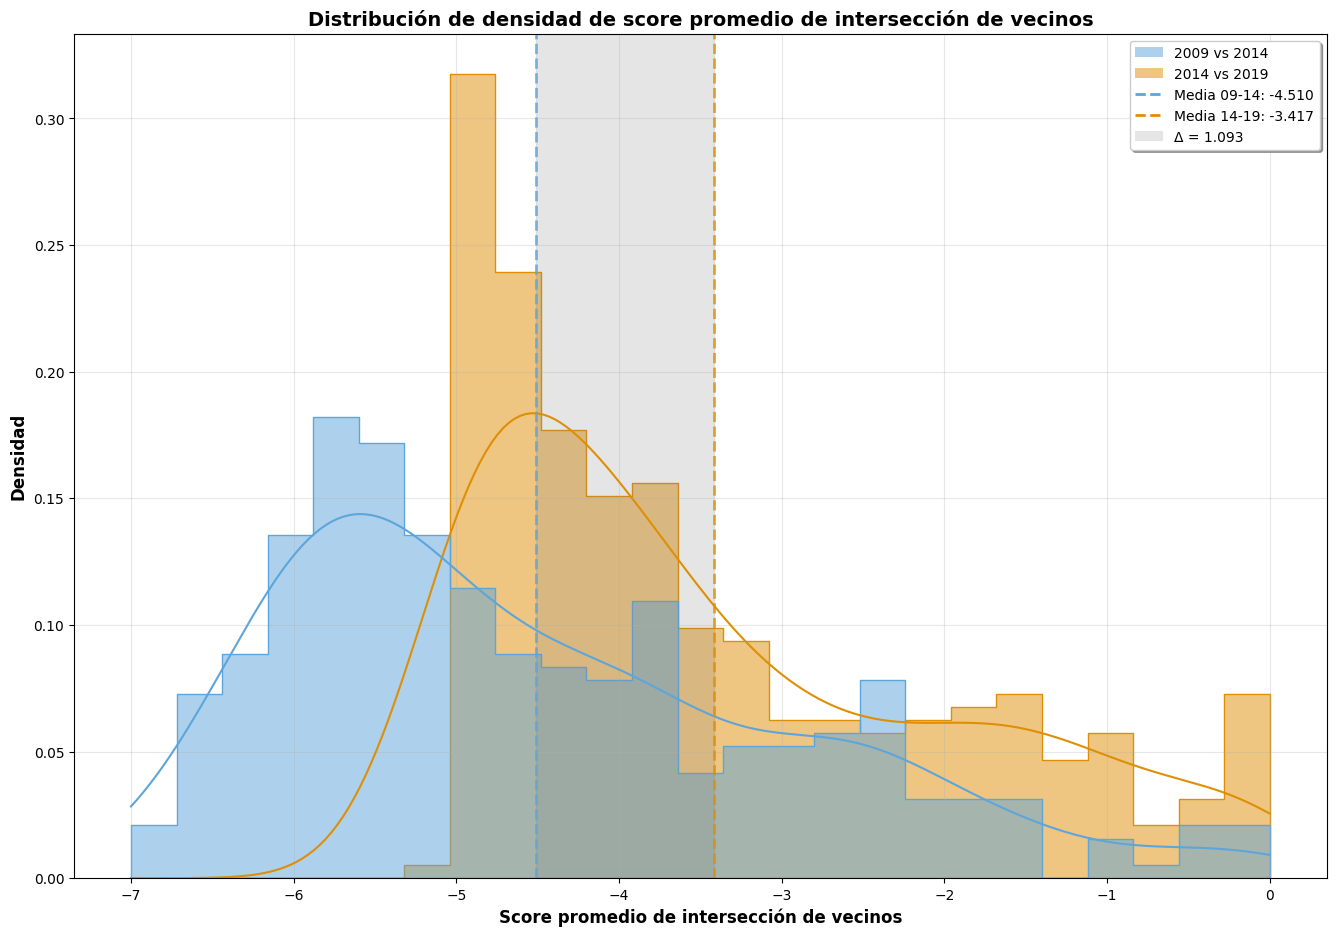

In [21]:
# Leyenda unificada y clara
from matplotlib.patches import Patch

# Paleta optimizada para similitud score
PALETA_score = {
    (2009, 2014): '#5DA5DA',  # Azul - tu color de proyectos de salud
    (2014, 2019): '#DE8F05'   # Naranja - tu color de tokens
}


plt.figure(figsize=(14, 10))
# Gráfico principal
sns.histplot(data=df_score, x='similaridad_semantica_mean', hue='par_periodo', 
             palette=PALETA_score,
             alpha=0.5, 
             bins=25,
             kde=True,
             element='step',
             stat='density')

plt.xlabel('Score promedio de intersección de vecinos', fontsize=12, fontweight='bold')
plt.ylabel('Densidad', fontsize=12, fontweight='bold')
plt.title('Distribución de densidad de score promedio de intersección de vecinos', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Calcular medias
media_2009_2014 = score_2009_2014.mean()
media_2014_2019 = score_2014_2019.mean()
diferencia_medias = abs(media_2009_2014 - media_2014_2019)

# Elementos visuales clave
plt.axvline(media_2009_2014, color=PALETA_score[(2009, 2014)], linestyle='--', linewidth=2, alpha=0.8)
plt.axvline(media_2014_2019, color=PALETA_score[(2014, 2019)], linestyle='--', linewidth=2, alpha=0.8)
plt.axvspan(min(media_2009_2014, media_2014_2019), max(media_2009_2014, media_2014_2019), 
            alpha=0.2, color='gray')


legend_elements = [
    Patch(facecolor=PALETA_score[(2009, 2014)], alpha=0.5, label='2009 vs 2014'),
    Patch(facecolor=PALETA_score[(2014, 2019)], alpha=0.5, label='2014 vs 2019'),
    plt.Line2D([0], [0], color=PALETA_score[(2009, 2014)], linestyle='--', linewidth=2, 
               label=f'Media 09-14: {media_2009_2014:.3f}'),
    plt.Line2D([0], [0], color=PALETA_score[(2014, 2019)], linestyle='--', linewidth=2, 
               label=f'Media 14-19: {media_2014_2019:.3f}'),
    Patch(facecolor='gray', alpha=0.2, label=f'Δ = {diferencia_medias:.3f}')
]

plt.legend(handles=legend_elements, loc='best', title='', frameon=True, shadow=True)

plt.tight_layout(pad=3)
plt.savefig(BASE_DIR+'imagenes/promedio_score.png', 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Distribución entre períodos


Para determinar que una palabra tiene cambio semántico entre los pares de periodos comparados (período 2009 vs período 2014 y período 2014 vs período 2019) se debe garantizar que :
* Se identifica la palabra como palabra consistentemente cambiantes en alguno de los pares de períodos comparados.
* El promedio de similaridad coseno asociado a la palabra es menor a 0.5 tal que:
    * Cambio fuerte: promedio de similaridad coseno  < 0.3
    * Cambio moderado: promedio de similaridad coseno entre 0.3 y 0.5

In [23]:
# Abrir
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)
basetotaltexto_df = basetexto_df.copy()  # todas las iniciativas
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 12)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 12)


In [24]:
def mostrar_ejemplos_contextuales_titulos2(df, palabra, periodo, n=5):
    """
    Versión mejorada que siempre retorna exactamente n elementos
    """
    try:
        # Validaciones iniciales
        if df.empty or pd.isna(palabra) or pd.isna(periodo):
            return ["Datos inválidos"] * n
        
        # Filtrar por periodo
        df_periodo = df[df['Periodo_5anios'] == periodo]
        
        if df_periodo.empty:
            return [f"No hay datos para periodo {periodo}"] * n
        
        # Filtrar títulos que contienen la palabra
        mask = df_periodo['Título normalizado'].str.lower().str.contains(
            palabra.lower(), na=False, regex=False
        )
        titulos_con_palabra = df_periodo[mask]
        
        if titulos_con_palabra.empty:
            return [f"No se encontró '{palabra}' en periodo {periodo}"] * n
        
        # Obtener ejemplos
        disponibles = min(n, len(titulos_con_palabra))
        ejemplos = titulos_con_palabra['Título'].str.lower().sample(
            n=disponibles, 
            random_state=42,
            replace=False
        ).tolist()
        
        # Rellenar si no hay suficientes
        while len(ejemplos) < n:
            ejemplos.append(f"Ejemplo adicional no disponible ({len(ejemplos)+1}/{n})")
        
        print(f"✓ '{palabra}' en {periodo}: {disponibles} ejemplos")
        return ejemplos
        
    except Exception as e:
        print(f"✗ Error con '{palabra}' en {periodo}: {e}")
        return [f"Error: {str(e)[:30]}..."] * n



In [26]:
for par_periodo in pares_periodo:
    print(pares_periodo)
    df = topn_periodo[par_periodo].sort_values('similaridad_semantica_mean', ascending=True).head(10)
    df['Ejemplos '+str(par_periodo[0])] = None
    df['Ejemplos '+str(par_periodo[1])] = None
    for index, row in df.iterrows():
        palabra = row['palabra']
        # Obtener los ejemplos contextuales
        ejemplos = mostrar_ejemplos_contextuales_titulos2(basetexto_df, palabra, par_periodo[0], n=5)
        df.loc[index, 'Ejemplos '+str(par_periodo[0])] = str(ejemplos)
        ejemplos = mostrar_ejemplos_contextuales_titulos2(basetexto_df, palabra, par_periodo[1], n=5)
        df.loc[index, 'Ejemplos '+str(par_periodo[1])] = str(ejemplos)
    df.to_csv(RESULTADOS_DIR+'NN_top20_'+str(par_periodo[0])+'_Ejemplo.csv', index=False)

[(2009, 2014), (2014, 2019)]
✓ 'humano' en 2009: 5 ejemplos
✓ 'humano' en 2014: 5 ejemplos
✓ 'pensionado' en 2009: 5 ejemplos
✓ 'pensionado' en 2014: 5 ejemplos
✓ 'diagnostico' en 2009: 5 ejemplos
✓ 'diagnostico' en 2014: 5 ejemplos
✓ 'gluten' en 2009: 5 ejemplos
✓ 'gluten' en 2014: 5 ejemplos
✓ 'institucion' en 2009: 5 ejemplos
✓ 'institucion' en 2014: 5 ejemplos
✓ 'lectivo' en 2009: 4 ejemplos
✓ 'lectivo' en 2014: 5 ejemplos
✓ 'nacido' en 2009: 5 ejemplos
✓ 'nacido' en 2014: 5 ejemplos
✓ 'instituir' en 2009: 5 ejemplos
✓ 'instituir' en 2014: 5 ejemplos
✓ 'destinado' en 2009: 5 ejemplos
✓ 'destinado' en 2014: 5 ejemplos
✓ 'especial' en 2009: 5 ejemplos
✓ 'especial' en 2014: 5 ejemplos
[(2009, 2014), (2014, 2019)]
✓ 'masivo' en 2014: 4 ejemplos
✓ 'masivo' en 2019: 5 ejemplos
✓ 'ano' en 2014: 5 ejemplos
✓ 'ano' en 2019: 5 ejemplos
✓ 'anti' en 2014: 5 ejemplos
✓ 'anti' en 2019: 5 ejemplos
✓ 'numerir' en 2014: 2 ejemplos
✓ 'numerir' en 2019: 5 ejemplos
✓ 'nacional' en 2014: 5 ejemplos
✓ '

In [27]:
# Convertir datos en DataFrame para visualización
def plot_heatmap(cambios_df, title, top = 10):
    #words, values = zip(*changed_words[:top])  # Tomamos el top 10
    #df = pd.DataFrame({"Palabra": words, "Cambio Semántico": values})
    df = cambios_df.copy()
    plt.figure(figsize=(14, 10))
    sns.heatmap(df.set_index("palabra").T, cmap="Reds_r", annot=True, fmt=".2f", linewidths=0.5)
    plt.title(title)
    plt.show()

def diferencia(par):
    return par[1] - par[0]

In [30]:
topk = 10
for par_periodo in pares_periodo:

    print(" Promedio de similaridad coseno  <= 0.3 , Cambio fuerte (usos muy distintos)")
    periodo_df = topn_Procustes_periodo[par_periodo]
    umbral_fuerte1 = 0.3
    periodo_df1 =  periodo_df[periodo_df['similaridad_semantica_mean']<=umbral_fuerte1].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    #periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True) # ordenado por dispersion

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Top 10 palabras con cambio semántico entre período "+str(par_periodo[0])+ " → "+str(par_periodo[1]), top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1) 
    print("Promedio de similaridad coseno  <= 0.5  Cambio moderado")

    umbral_fuerte2 = 0.5
    periodo_df1 =  periodo_df[(periodo_df['similaridad_semantica_mean']<=umbral_fuerte2) & (periodo_df['similaridad_semantica_mean']>umbral_fuerte1)].sort_values('similaridad_semantica_mean', ascending=True).head(topk)
    periodo_df1["dispersion"] = periodo_df1['similaridad_semantica_confidence_intervals'].apply(diferencia)
    #periodo_df1 =  periodo_df1.sort_values('dispersion', ascending=True)

    # Graficar Heatmaps
    plot_heatmap(periodo_df1[['palabra','similaridad_semantica_mean']], "Top 10 palabras con cambio semántico entre período "+str(par_periodo[0])+ " → "+str(par_periodo[1]), top=topk)
    print("TOP 10 Palabras:", periodo_df1['palabra'].unique())
    display(periodo_df1[['par_periodo', 	'palabra', 	'similaridad_semantica_mean' 	,'vt1_top10' 	,'vt2_top10', 	'vt1_top10_union' 	,'vt2_top10_union', 	'dispersion','similaridad_semantica_confidence_intervals' 	]])  

 Promedio de similaridad coseno  <= 0.3 , Cambio fuerte (usos muy distintos)


NameError: name 'topn_Procustes_periodo' is not defined

#### Análisis técnico y contextual palabra por palabra, considerando:

* El valor promedio de similaridad coseno (similaridad_semantica_mean): cuanto más bajo, mayor cambio semántico.

* El contenido de las vecindades (vt1_top10, vt2_top10) por intersección de 50 iteraciones.

* Las vecindades por unión (vt1_top10_union, vt2_top10_union) como panorama más amplio del contexto semántico.

* La dispersión, que indica variabilidad en las 50 iteraciones.

#### 🔴Palabras con cambio semántico fuerte
**Par de período (2009, 2014)**
*  'legal' 'declaracion'
  
**Par de período (2014, 2019)**
* dispositivo' 'adecuado' 'accesibilidad'

#### 🟡Palabras con cambio semántico moderado
**Par de período (2009, 2014)**
* 'respectivamente' 'empleo' 'materia' 'el' 'tipo' 'ingreso' 'patologia'
 'territorio' 'pre' 'acompanante'


**Par de período (2014, 2019)**
* 'forma' 'tipo' 'domiciliario' 'comunitario' 'necesario' 'educacion'
 'pais' 'manejo' 'obligacion' 'sustancia'

*Para tener en cuenta*

* ¿Detectar reorientaciones en las prioridades discursivas del Congreso?.

* ¿Entender cómo ciertos términos como acompañante, recurso, territorio se adaptan a nuevos marcos legales o institucionales?.

* ¿Servir de insumo para organizaciones que monitorean derechos y acceso a salud, alertando sobre cambios sutiles en el lenguaje parlamentario que pueden reflejar transformaciones más profundas?.

##### Palabras comunes en entre todos los períodos


In [ ]:
palabra_comun = set(topn_periodo[(2009, 2014)]['palabra'].unique()) & set(topn_periodo[(2014, 2019)]['palabra'].unique())
print("Cantidad de palabras en común:",len(palabra_comun))

In [ ]:
# Período (2009, 2014)
df = topn_periodo[(2009, 2014)]
df = df[df['palabra'].isin(palabra_comun)]
df = df[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df.columns = ['palabra','ss_mean_2009_2014','ss_ci_2009_2014','vt1_top10_2009_2014','vt2_top10_2009_2014']
 
# Período (2014, 2019)
df2 = topn_periodo[(2014, 2019)]
df2 = df2[df2['palabra'].isin(palabra_comun)]
df2 = df2[['palabra','similaridad_semantica_mean','similaridad_semantica_confidence_intervals','vt1_top10','vt2_top10']]
df2.columns = ['palabra','ss_mean_2014_2019','ss_ci_2014_2019','vt1_top10_2014_2019','vt2_top10_2014_2019']

# Unión
df = df.merge(df2, how='inner', on='palabra')
df = df[['palabra', 'ss_mean_2009_2014', 'ss_mean_2014_2019', 'ss_ci_2009_2014','ss_ci_2014_2019','vt1_top10_2009_2014','vt2_top10_2009_2014', 'vt1_top10_2014_2019','vt2_top10_2014_2019']]
df['peso'] = (df['ss_mean_2009_2014'] + df['ss_mean_2014_2019'] )/2
df['diferencia'] = abs(df['ss_mean_2009_2014'] - df['ss_mean_2014_2019'] )

df.sort_values(['peso','diferencia']).to_csv(RESULTADOS_DIR+'procruste_top20_COM.csv', index=False)


print("Top 10 de palabras comunes con fuerte cambio semántico")
print("Palabras:",df[df['peso']<=0.3].sort_values('peso').head(10)['palabra'].unique() )
display(df[df['peso']<=0.3].sort_values('peso').head(10))
print("Top 10 de palabras comunes con moderado cambio semántico")
print("Palabras:",df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values('peso').head(10)['palabra'].unique() )
display(df[(df['peso']>0.3) & (df['peso']<=0.5)].sort_values(['peso','diferencia']).head(10))

* Cantidad de palabras en común: 276
* Las 10 palabras comunes entre pares de periodos comparados consecutivos con mayor peso de cambio semántico moderado son ['tipo' 'legal' 'ingreso' 'materia' 'forma' 'argentina' 'comunitario'
 'respectivamente' 'domiciliario' 'derivado'] .El peso es el promedio de similaridad coseno promedio para los pares de períodos comparados.
    * No aparece 'declaracion', pero aparecen ['legal'] de las palabras de fuerte cambio semántico en (2009-2014). En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'respectivamente' , ',materia', 'tipo', 'ingreso'. 
    * No aparecen ninguna de las palabras ['dispositivo', 'adecuado', 'accesibilidad'] de fuerte cambio semántico en (2014-2019).En relación a cambio semántico de las palabras identificadas con cambio moderado, solo aparecen en palabras en comunes 'forma', 'tipo', 'domiciliario', 'comunitario'.. 
    * La palabra 'argentina' aparece entre las palabas de cambio moderado, cuando antes no estaba en top 10.





#### Identificar vecindades de palabras

La vecindad de una palabra, son las N palabras más asociadas al período quinquinal observado. Por ejemplo: la palabra 'dispositivo' en el período 2014 estaba más asociado a las palabras {electronico, similar, dato, nocivo} tal para el período 2019 estaba más relacionado con {desfibrilador, instalacion, tecnologico, subitar, concurrencia}.

Se busca las n palabras más similares (por similut coseno) a una palabra objetivo y así poder interpretar el posible cambio semantico. Para más información: https://tedboy.github.io/nlps/generated/generated/gensim.models.Word2Vec.most_similar.html

In [ ]:
# Directorio con modelo de embedding alineados por procrustes correspondiente a i = 0
alin_dir = modelo_dir +'/estabilidad_procrustes/alineado/'
i = 0

In [ ]:
# Inicializar estructura de vectores por palabra
from collections import defaultdict
vectores_por_palabra = {}
vectores_promedio = {}

def get_vector_modelo(vectores,periodo,i):
    modelo = Word2Vec.load(alin_dir+"alin_" + str(periodo)+'_'+str(i)+'.mdl')
    for palabra in modelo.wv.key_to_index:
        vectores[palabra].append(modelo.wv[palabra])
    return vectores
    
for periodo in [2009,2014,2019]:
    # Por período
    vectores_por_palabra[periodo] = defaultdict(list)
    for i in range(50):
        vectores_por_palabra[periodo] = get_vector_modelo(vectores_por_palabra[periodo],periodo,i)
    #Calcular vector medio solo para palabras con presencia en todas las iteraciones (opcional)
    vectores_promedio[periodo] = {pal: np.mean(vs, axis=0) for pal, vs in vectores_por_palabra[periodo].items() if len(vs) == 50}

In [ ]:
## 2. Visualización del desplazamiento con t-SNE
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.manifold import TSNE
from scipy.spatial.distance import cosine


def compute_cosine_similarity(model1,model2,word):
    vector1 = model1.wv[word].reshape(1,-1)
    vector2 = model2.wv[word].reshape(1,-1)
    return(cosine_similarity(X=vector1, Y=vector2)[0][0])

def reducir_dimensionalidad( embeddings, n_components=2, perplexity=5, palabrasComun = []):
    if len(palabrasComun)>0:
        words = palabrasComun
    else:
        words = list(embeddings.keys())
    
    vectors = np.array([embeddings.wv.get_vector(word)  for word in words])
    #embeddings[word]  
    tsne = TSNE(n_components=n_components, perplexity=perplexity, random_state=42)
    reduced_vectors = tsne.fit_transform(vectors)
    
    return reduced_vectors



def plot_neighbors_tsne(word, embeddings_by_period, alineados=None, periods=None, top_k=10):

    all_vectors, all_labels, all_colors = [], [], []
    center_positions = {}

    # Paleta accesible para daltonismo
    color_palette = sns.color_palette("colorblind", len(periods))

    for i, period in enumerate(periods):
        if word not in embeddings_by_period[period]:
            print(f"'{word}' no está en el vocabulario del período {period}")
            continue

        vocab = embeddings_by_period[period]

        if alineados:
            vecinos = alineados[period].wv.most_similar(positive=[word], topn=top_k)
            print(period)
            print(vecinos)
            neighbors = [w for w, _ in vecinos] + [word]
        else:
            vecinos = sorted(
                vocab.items(),
                key=lambda kv: cosine(vocab[word], kv[1])
            )[1:top_k+1]
            neighbors = [w for w, _ in vecinos] + [word]

        for w in neighbors:
            all_vectors.append(vocab[w])
            all_labels.append(w)
            all_colors.append(color_palette[i])

    if all_vectors:
        tsne = TSNE(n_components=2, perplexity=5, random_state=0)
        X_2d = tsne.fit_transform(np.array(all_vectors))

        plt.figure(figsize=(16, 10))
        ax = plt.gca()
        ax.set_facecolor('white')  # Fondo blanco
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)
        ax.spines['bottom'].set_visible(True)
        ax.spines['left'].set_visible(True)

        for i, (x, label) in enumerate(zip(X_2d, all_labels)):
            plt.scatter(x[0], x[1], color=all_colors[i], s=70, edgecolor='black', linewidth=0.6)
            fontsize = 14 if label == word else 11
            weight = 'bold' if label == word else 'normal'

            # Separación de etiquetas: se desplazará ligeramente del punto
            offset = 1 if label == word else 0.5
            plt.text(x[0] + offset, x[1] + offset, label, fontsize=fontsize,
                     fontweight=weight, color='black',
                     bbox=dict(facecolor='white', edgecolor='none', pad=0.2))

        # Identificar y trazar los centros
        index = 0
        for i, period in enumerate(periods):
            if word in embeddings_by_period[period]:
                center_positions[period] = X_2d[index + top_k]
                index += top_k + 1

        # Flechas de cambio semántico
        for i in range(len(periods) - 1):
            p1, p2 = periods[i], periods[i+1]
            if p1 in center_positions and p2 in center_positions:
                start, end = center_positions[p1], center_positions[p2]
                plt.arrow(start[0], start[1], end[0]-start[0], end[1]-start[1],
                          color='gray', linewidth=1.5, head_width=0.5, length_includes_head=True)

                mid_x = (start[0] + end[0]) / 2
                mid_y = (start[1] + end[1]) / 2
                plt.text(mid_x, mid_y, f'{p2}', fontsize=10, ha='center',
                         va='center', backgroundcolor='white')

        # Leyenda
        for i, period in enumerate(periods):
            plt.scatter([], [], color=color_palette[i], label=str(period))
        plt.legend(title='Período', loc='upper left', fontsize=11)

        plt.title(f"Evolución semántica de '{word}' por quinquenios", fontsize=16, weight='bold')
        plt.axis('off')  # Mostrar bordes del gráfico
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.savefig(modelo_dir+'/estabilidad_procrustes/estabilidad_procrustes_'+word)
        plt.tight_layout()
        plt.show()
        plt.clf()       # Limpia el contenido actual de la figura
        plt.close()     # Cierra la figura actual

In [ ]:
# Para graficar
i = 0
vectores_alineados = {}
modelos_alineados = {}
vocab = {}
for periodo in [2009,2014,2019]:
    modelo = Word2Vec.load(alin_dir+"alin_" + str(periodo)+'_'+str(i)+'.mdl')
    vocab = {word: modelo.wv.get_vector(word) for word in modelo.wv.key_to_index}  # NUEVO vocab cada vez
    vectores_alineados[periodo]=  vocab
    modelos_alineados[periodo] = modelo

**Enfoque de explorar la iteración 0**

In [ ]:
top10pal_comunes_df = df.sort_values(['peso']).head(10)
top10pal = list(top10pal_comunes_df['palabra'].values)
top10pal

In [ ]:
top10pal_comunes_df

Las gráficas siguientes nos permiten visualizar cómo cambia el contexto semántico de una palabra específica a lo largo de periodos quinquenales, representando:
* Sus vecinos más similares (por word embeddings alineados por enfoque Procustes) en cada período.
* Su posición central (vector) en un espacio reducido a 2 dimensiones con t-SNE.
* Las flechas indican el desplazamiento del significado entre períodos.

**Para interpretar**
* Colores y períodos
    * Cada color representa un período (por ejemplo: 2009, 2014, 2019).
    * Todos los puntos del mismo color corresponden a la palabra de interés y sus vecinos en ese período.
    * Usá la leyenda para saber a qué período corresponde cada color.

* Puntos o destacados
    * El punto de la palabra clave (por ejemplo 'obligacion') suele estar con etiqueta en negrita.
    * Los vecinos más similares están alrededor, mostrando con qué palabras compartía contexto en ese momento.

* Flechas de cambio
    * Las flechas conectan el centro de cada período.
    * Muestran cómo se movió la palabra en el espacio semántico entre dos períodos consecutivos.
    * Si la dirección cambia mucho, sugiere cambio semántico fuerte.

* Distancia entre períodos
* Una distancia grande entre las posiciones de la palabra en distintos períodos sugiere cambios de significado o de contexto de uso.
* Una distancia corta indica estabilidad semántica.



In [ ]:
for palabra in top10pal : 
    plot_neighbors_tsne(palabra, vectores_alineados,modelos_alineados, [2009,2014,2019], top_k=10)

En un gráfico t-SNE las palabras más similares deberían aparecer más cerca unas de otras. Pero en la práctica, hay varios factores que pueden distorsionar esta expectativa.

**Para tener en cuenta**
¿Cuáles vecinos persisten entre períodos? (mismo contexto).
¿Qué palabras nuevas aparecen en los vecinos más similares? (nuevos usos).
¿Cuáles se desvanecen o ya no son vecinos relevantes?
¿Qué tan cohesivo o disperso es el grupo de vecinos?



## Análisis proyectos de ley asociados a términos con cambio fuerte y moderado

In [ ]:
# Abrir
with open(os.getenv("DIR_DATOS_PROCESADOS") + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

In [ ]:
# Seleccionando IL de Salud
# Supongamos que estos son tus 3 DataFrames ya filtrados
basetotaltexto_df = basetexto_df.copy()  # todas las iniciativas
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

In [ ]:
#pal = set(['legal', 'declaracion']).union(set(['acompanante', 'dengue', 'recurso' ,'tipo' ,'patologia', 'comunitario','empleo', 'ingreso' ,'territorio']))
#pal = pal.union(set( ['comunitario', 'adecuado', 'dispositivo'])).union(set(['necesario', 'materia', 'suplemento', 'obligacion' ,'tipo', 'gratuidad','forma' ,'domiciliario' ,'pais' ,'accesibilidad']))
#pal = pal.union(set(top10pal))
pal = top10pal # list(pal)  

In [ ]:
# Convertimos a minúscula y verificamos si la palabra aparece en el título
for palabra in pal:
    basetexto_df[palabra] = basetexto_df['Título normalizado'].str.contains(rf'\b{palabra}\b', case=False)

In [ ]:
proyectos_relevantes = basetexto_df[basetexto_df[pal].any(axis=1)]
print("Cantidad de proyectos asociados a las palabras con cambio semántico':" ,proyectos_relevantes.shape[0])
print("% :" , round((proyectos_relevantes.shape[0]/basetexto_df.shape[0]) * 100,2))

In [ ]:
frecuencias_df = basetexto_df[['Año']+top10pal].groupby(['Año']).sum().T#reset_index()
frecuencias_df['total'] = frecuencias_df.sum(axis=1) 
frecuencias_df = frecuencias_df.sort_values('total', ascending=True)
# Cantidad de proyectos por año (para normalizar)
#total_proyectos_por_anio = basetexto_df.groupby('Año').size()
# frecuencia_df tiene palabras como índice y años como columnas (frecuencia absoluta)
#frecuencia_relativa_df = frecuencias_df.div(total_proyectos_por_anio, axis=1) * 100  # multiplicamos por 100 para %
frecuencia_relativa_df = frecuencias_df.div(frecuencias_df['total'], axis=0) * 100  # multiplicamos por 100 para %
frecuencia_relativa_df = frecuencia_relativa_df.drop(columns='total')
# Ordenar por promedio total para ordenar mejor las barras
#frecuencia_relativa_df['Promedio'] = frecuencia_relativa_df.mean(axis=1)
#frecuencia_relativa_df = frecuencia_relativa_df.sort_values('Promedio', ascending=True).drop(columns='Promedio')

In [ ]:
frecuencias_df

In [ ]:
plt.figure(figsize=(14, 10))
sns.set(font_scale=0.9)

# Crear una versión formateada como texto con % para anotar
annot_text = frecuencia_relativa_df.round(1).astype(str) + '%'

# Paleta perceptualmente uniforme, buena para datos proporcionales
sns.heatmap(
    frecuencia_relativa_df,
    cmap="YlOrRd",           # o usa "viridis", "cividis" para daltónicos
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Frecuencia relativa (%)'},
    vmin=1,                  # valor mínimo en escala de color
    vmax=50,                 # valor máximo
    annot=annot_text,  # Mostrar los valores como texto
    fmt='',             # Ya están formateados como string
    annot_kws={"size": 8}  # Tamaño del texto en las celdas
)
plt.title('Presencia relativa de palabras con cambios moderado en proyectos de ley sobre salud (2009–2024)', fontsize=14)
plt.xlabel('Año')
plt.ylabel('Palabra clave')
plt.tight_layout()
plt.show()

In [ ]:
def mostrar_ejemplos_contextuales_titulos(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de títulos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de títulos) y 'periodo'.
        palabra (str): La palabra para buscar en los títulos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    titulos_con_palabra = df_periodo[df_periodo['Título normalizado'].str.lower().str.contains(palabra.lower(), na=False)]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de títulos conteniendo '{palabra}' en el periodo {periodo}:")
        display(titulos_con_palabra[['Título','Título normalizado']].head(n))
    
    else:
        print(f"No se encontraron títulos conteniendo '{palabra}' en el periodo {periodo}.")


**Comunitario**

In [ ]:
proyectos_relevantes.loc[proyectos_relevantes['legal']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

**Tipo**

In [ ]:
proyectos_relevantes.loc[proyectos_relevantes['tipo']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)

**Comunitario**

In [ ]:
proyectos_relevantes.loc[proyectos_relevantes['comunitario']==True,['Proyecto.ID','Año','Título','Resultado'],].sort_values(by='Año', ascending = False)